# BIFROST — Fiber Deployment & Spinning Example

This notebook demonstrates:
1. Loading a fiber deployment with spinning enabled on all segments
2. Inspecting the link structure (spun segments, pole wraps, hinges)
3. Comparing constant vs sinusoidal spin profiles
4. PMD suppression analysis (Bessel/Floquet theory)
5. Raman and Brillouin scattering spectra
6. Monte Carlo with the hinge model for long spun fiber links
7. Validating the analytical spinning formulas against numerical ODE integration

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import json

import bifrost as bf
import spinning
import deploy

import raman
import brillouin

## 1. Load the deployment

The JSON config specifies a ~800 m fiber route with three sections.
Spinning is a fiber-level property: the entire spool was spun during
manufacturing, so all straight segments are `SpunFiberLength` objects.
Pole wraps and the paddle controller are NOT spun.

In [3]:
dep = deploy.load_deployment('example_deployment.json')
deploy.print_deployment_summary(dep)

Section                                   Env           T (°C)  Objects  Length (m)
----------------------------------------------------------------------------------
  Underground duct — campus to building A  underground     15.0        3      500.00  splices: [0.05]
  Aerial span — building A to building B  aerial          35.0        6      264.71
  Indoor — building B patch panel         indoor          22.0        4       36.12

  Total length: 800.8 m
  Total objects: 13
  Object types: {'SpunFiberLength': 7, 'Rotator': 3, 'FiberLength': 2, 'FiberPaddleSet': 1}


## 2. Per-segment properties

Each straight run uses the sinusoidal spin formula with modulation index m=10.
Pole wraps are ordinary `FiberLength` objects with bending birefringence.
Rotators appear at the splice and at section boundaries.

In [4]:
deploy.print_segment_table(dep)

  #  Type                     L (m)        Spin  T (°C)
------------------------------------------------------------
  0  SpunFiberLength        200.000    sin m=10    15.0
  1  Rotator                  0.000           —       —
  2  SpunFiberLength        300.000    sin m=10    15.0
  3  Rotator                  0.000           —       —
  4  SpunFiberLength         80.000    sin m=10    35.0
  5  FiberLength              2.827  bend r=0.15    35.0
  6  SpunFiberLength        120.000    sin m=10    35.0
  7  FiberLength              1.885  bend r=0.15    35.0
  8  SpunFiberLength         60.000    sin m=10    35.0
  9  Rotator                  0.000           —       —
 10  SpunFiberLength         30.000    sin m=10    22.0
 11  FiberPaddleSet           1.116           —    22.0
 12  SpunFiberLength          5.000    sin m=10    22.0


In [5]:
# Detailed view: DGD per object
print(f"{'#':>3}  {'Type':20s}  {'L (m)':>8}  {'T (°C)':>6}  {'DGD (ps)':>9}")
print('-' * 55)
for i, f in enumerate(dep['fibers']):
    name = type(f).__name__
    L = f.L0
    T_str = f'{f.T0:.0f}' if hasattr(f, 'T0') else '—'
    if hasattr(f, 'calcDGD') and f.L0 > 0:
        dgd_ps = f.calcDGD() * 1e12
        print(f'{i:>3}  {name:20s}  {L:>8.3f}  {T_str:>6}  {dgd_ps:>9.4f}')
    else:
        print(f'{i:>3}  {name:20s}  {L:>8.3f}  {T_str:>6}  {"—":>9}')

  #  Type                     L (m)  T (°C)   DGD (ps)
-------------------------------------------------------
  0  SpunFiberLength        200.000      15     0.0162
  1  Rotator                  0.000       —          —
  2  SpunFiberLength        300.000      15     0.0243
  3  Rotator                  0.000       —          —
  4  SpunFiberLength         80.000      35     0.0064
  5  FiberLength              2.827      35     0.0004
  6  SpunFiberLength        120.000      35     0.0097
  7  FiberLength              1.885      35     0.0000
  8  SpunFiberLength         60.000      35     0.0048
  9  Rotator                  0.000       —          —
 10  SpunFiberLength         30.000      22     0.0024
 11  FiberPaddleSet           1.116      22          —
 12  SpunFiberLength          5.000      22     0.0004


## 3. Full-link polarisation analysis

In [6]:
J_total = deploy.compute_jones(dep)
print('Total Jones matrix:')
print(np.array2string(J_total, precision=4, suppress_small=True))
print(f'|det| = {np.abs(np.linalg.det(J_total)):.10f}')
print()

dgd = deploy.compute_dgd(dep)
L_km = deploy.compute_total_length(dep) / 1e3
print(f'Total DGD: {dgd*1e12:.4f} ps')
print(f'PMD coefficient: {dgd*1e12 / np.sqrt(L_km):.4f} ps/sqrt(km)')
print(f'Total length: {deploy.compute_total_length(dep):.1f} m')

# Also extract computed fiber parameters for use later
fparams = deploy.get_fiber_params(dep)
print(f"\nFiber nonlinear coefficient gamma = {fparams['gamma']:.4e} W⁻¹m⁻¹")
print(f"Effective mode area A_eff = {fparams['Aeff']*1e12:.1f} um²")
print(f"GeO2 mole fraction = {fparams['m_GeO2']}")

Total Jones matrix:
[[ 0.8026-0.2321j  0.413 -0.3624j]
 [-0.413 -0.3624j  0.8026+0.2321j]]
|det| = 1.0000000000

Total DGD: 0.0282 ps
PMD coefficient: 0.0315 ps/sqrt(km)
Total length: 800.8 m

Fiber nonlinear coefficient gamma = 1.1189e-03 W⁻¹m⁻¹
Effective mode area A_eff = 82.8 um²
GeO2 mole fraction = 0.036


## 4. Constant vs sinusoidal spin comparison

For the same intrinsic birefringence, compare:
- Unspun fiber (plain `FiberLength`)
- Constant spin rate (`SpunFiberLength`, spin_type='constant')
- Sinusoidal spin rate (`SpunFiberLength`, spin_type='sinusoidal')

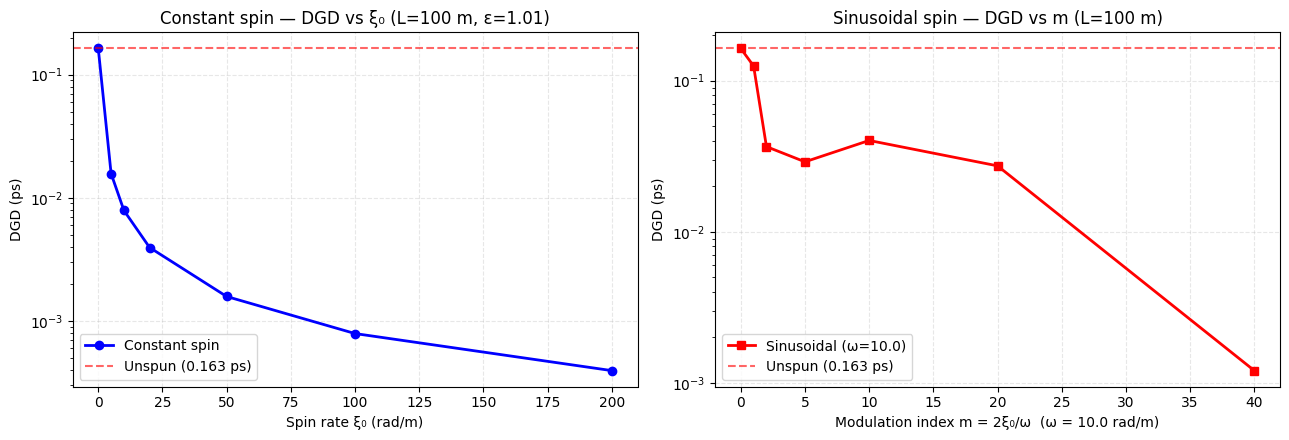

Unspun DGD: 0.1634 ps
Constant ξ₀=50: 0.0016 ps  (suppression 103×)
Sinusoidal m=10: 0.0366 ps  (suppression 4×)


In [7]:
# Common parameters
L_test = 100       # m
eps_test = 1.01    # exaggerated noncircularity for visibility
common = dict(w0=1550e-9, T0=25, L0=L_test, r0=4.1e-6, r1=62.5e-6,
              epsilon=eps_test, m0=0.036, m1=0.0, Tref=20, rc=0, tf=0, tr=0)

# 1. Unspun
f_unspun = bf.FiberLength(**common)
dgd_unspun = f_unspun.calcDGD() * 1e12

# 2. Constant spin at several rates
xi_arr = np.array([0, 5, 10, 20, 50, 100, 200])
dgd_const = []
for xi in xi_arr:
    if xi == 0:
        dgd_const.append(dgd_unspun)
    else:
        f = bf.SpunFiberLength(**common, xi0=xi, spin_type='constant')
        dgd_const.append(f.calcDGD() * 1e12)

# 3. Sinusoidal spin at several modulation indices
omega_test = 10.0  # rad/m
xi_sin_arr = np.array([0, 5, 10, 25, 50, 100, 200])
dgd_sin = []
for xi in xi_sin_arr:
    if xi == 0:
        dgd_sin.append(dgd_unspun)
    else:
        f = bf.SpunFiberLength(**common, xi0=xi, spin_type='sinusoidal',
                               omega=omega_test)
        dgd_sin.append(f.calcDGD() * 1e12)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.semilogy(xi_arr, dgd_const, 'bo-', lw=2, label='Constant spin')
ax1.axhline(dgd_unspun, color='r', ls='--', alpha=0.6, label=f'Unspun ({dgd_unspun:.3f} ps)')
ax1.set_xlabel('Spin rate ξ₀ (rad/m)')
ax1.set_ylabel('DGD (ps)')
ax1.set_title(f'Constant spin — DGD vs ξ₀ (L={L_test} m, ε={eps_test})')
ax1.legend()
ax1.grid(True, ls='--', alpha=0.3)

m_arr_plot = 2 * xi_sin_arr / omega_test
ax2.semilogy(m_arr_plot, dgd_sin, 'rs-', lw=2, label=f'Sinusoidal (ω={omega_test})')
ax2.axhline(dgd_unspun, color='r', ls='--', alpha=0.6, label=f'Unspun ({dgd_unspun:.3f} ps)')
ax2.set_xlabel(f'Modulation index m = 2ξ₀/ω  (ω = {omega_test} rad/m)')
ax2.set_ylabel('DGD (ps)')
ax2.set_title(f'Sinusoidal spin — DGD vs m (L={L_test} m)')
ax2.legend()
ax2.grid(True, ls='--', alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Unspun DGD: {dgd_unspun:.4f} ps')
print(f'Constant ξ₀=50: {dgd_const[4]:.4f} ps  (suppression {dgd_unspun/dgd_const[4]:.0f}×)')
print(f'Sinusoidal m=10: {dgd_sin[2]:.4f} ps  (suppression {dgd_unspun/dgd_sin[2]:.0f}×)')

## 5. Floquet suppression theory

The Floquet analysis shows that sinusoidal spinning with modulation index
m = 2ξ₀/ω renormalises the effective birefringence as β_eff = δ₀ · J₀(m).
At the zeros of J₀, the leading-order PMD vanishes.

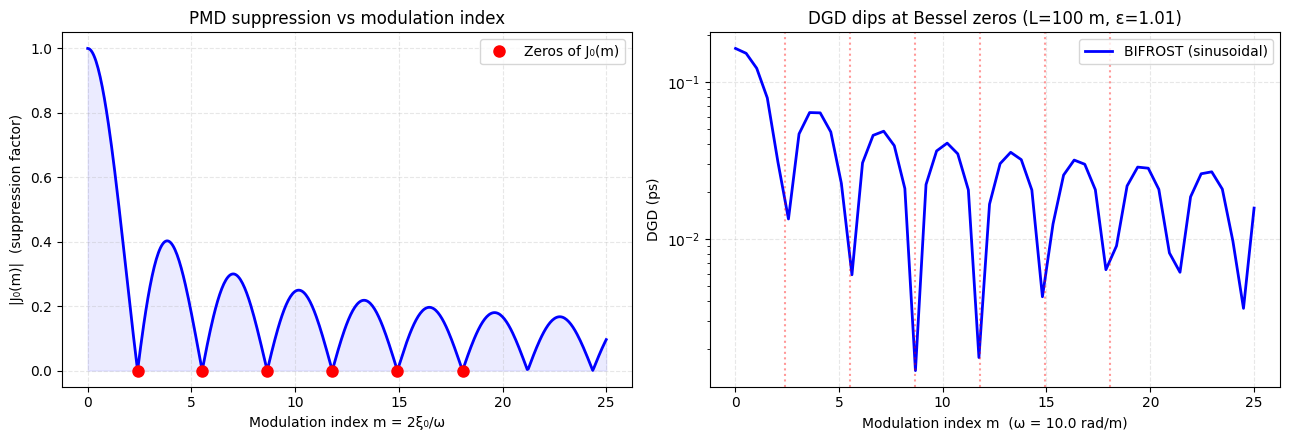

First 6 Bessel zeros: [ 2.405  5.52   8.654 11.792 14.931 18.071]


In [8]:
from scipy.special import jv

m_arr = np.linspace(0, 25, 500)
suppression = np.abs(jv(0, m_arr))
zeros = spinning.optimal_modulation_indices(6)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: suppression factor
ax1.plot(m_arr, suppression, 'b-', lw=2)
ax1.plot(zeros, np.zeros_like(zeros), 'ro', ms=8, label='Zeros of J₀(m)')
ax1.fill_between(m_arr, 0, suppression, alpha=0.08, color='blue')
ax1.set_xlabel('Modulation index m = 2ξ₀/ω')
ax1.set_ylabel('|J₀(m)|  (suppression factor)')
ax1.set_title('PMD suppression vs modulation index')
ax1.legend()
ax1.grid(True, ls='--', alpha=0.3)
ax1.set_ylim(-0.05, 1.05)

# Right: DGD scan over m using SpunFiberLength
omega_scan = 10.0
xi_scan = np.linspace(0.1, 125, 50)
m_scan = 2 * xi_scan / omega_scan
dgd_scan = []
for xi in xi_scan:
    sf = bf.SpunFiberLength(**common, xi0=xi, spin_type='sinusoidal',
                            omega=omega_scan)
    dgd_scan.append(sf.calcDGD() * 1e12)

ax2.semilogy(m_scan, dgd_scan, 'b-', lw=2, label='BIFROST (sinusoidal)')
for z in zeros:
    if z < m_scan[-1]:
        ax2.axvline(z, color='r', ls=':', alpha=0.4)
ax2.set_xlabel(f'Modulation index m  (ω = {omega_scan} rad/m)')
ax2.set_ylabel('DGD (ps)')
ax2.set_title(f'DGD dips at Bessel zeros (L={L_test} m, ε={eps_test})')
ax2.legend()
ax2.grid(True, ls='--', alpha=0.3)

plt.tight_layout()
plt.show()

print('First 6 Bessel zeros:', np.round(zeros, 3))

## 6. Validate Floquet formula against direct ODE integration

The analytical Floquet result (keeping only the n=0 Bessel harmonic) is an
approximation. The exact numerical ODE and the subdivision method should agree;
the Floquet error shrinks as ω/δ increases.

In [9]:
from scipy.integrate import solve_ivp

delta0 = 5.0; xi0 = 200.0; omega = 40.0
T_spin = 2 * np.pi / omega
L_val = 20 * T_spin

# Direct ODE integration (ground truth)
def ode_rhs(z, y):
    theta_z = (xi0 / omega) * np.sin(omega * z)
    phase = 2 * theta_z
    cp, sp = np.cos(phase), np.sin(phase)
    cm = -1j/2 * delta0 * (cp - 1j*sp)
    cpl = -1j/2 * delta0 * (cp + 1j*sp)
    E1 = y[0]+1j*y[1]; R1 = y[2]+1j*y[3]
    E2 = y[4]+1j*y[5]; R2 = y[6]+1j*y[7]
    d1 = cm*R1; d2 = cpl*E1; d3 = cm*R2; d4 = cpl*E2
    return [d1.real,d1.imag,d2.real,d2.imag,
            d3.real,d3.imag,d4.real,d4.imag]

sol = solve_ivp(ode_rhs, [0, L_val], [1,0,0,0, 0,0,1,0],
                method='DOP853', rtol=1e-12, atol=1e-14, max_step=L_val/10000)
yf = sol.y[:, -1]
Jc = np.array([[yf[0]+1j*yf[1], yf[4]+1j*yf[5]],
               [yf[2]+1j*yf[3], yf[6]+1j*yf[7]]])
T_mat = np.array([[1,1j],[1,-1j]]) / np.sqrt(2)
T_inv = np.array([[1,1],[-1j,1j]]) / np.sqrt(2)
J_ode = T_inv @ Jc @ T_mat

# Numerical subdivision
J_num = spinning.calc_J_numerical(
    delta0, lambda z: xi0 * np.cos(omega * z), L_val, N=50000)

# Floquet analytic
J_flo, info = spinning.calc_J_sinusoidal(delta0, xi0, omega, L_val)

print(f'Parameters: delta={delta0}, xi0={xi0}, omega={omega}, m={info["m"]}')
print(f'L = {L_val/T_spin:.0f} spin periods = {L_val:.3f} m')
print()
print(f'ODE vs numerical subdivision:  {np.max(np.abs(J_ode - J_num)):.2e}  (should be ~1e-6)')
print(f'ODE vs Floquet analytic:       {np.max(np.abs(J_ode - J_flo)):.4f}  (Floquet approx error)')
print()
print(f'{"delta":>8}  {"omega/delta":>12}  {"Floquet error":>14}')
print('-' * 38)
for d in [0.5, 1.0, 5.0, 10.0, 20.0]:
    Jf, _ = spinning.calc_J_sinusoidal(d, xi0, omega, L_val)
    Jn = spinning.calc_J_numerical(d, lambda z: xi0*np.cos(omega*z), L_val, N=30000)
    print(f'{d:>8.1f}  {omega/d:>12.1f}  {np.max(np.abs(Jf - Jn)):>14.6f}')

Parameters: delta=5.0, xi0=200.0, omega=40.0, m=10.0
L = 20 spin periods = 3.142 m

ODE vs numerical subdivision:  1.79e-06  (should be ~1e-6)
ODE vs Floquet analytic:       0.0217  (Floquet approx error)

   delta   omega/delta   Floquet error
--------------------------------------
     0.5          80.0        0.000448
     1.0          40.0        0.001757
     5.0           8.0        0.021742
    10.0           4.0        0.030470
    20.0           2.0        0.087749


## 7. Raman scattering spectra

Three Raman response function models:
- **Blow–Wood** (1989): single damped oscillator, analytic closed form
- **Hollenbeck–Cantrell** (2002): 13 vibrational modes, captures the 15 THz shoulder
- **Lin–Agrawal tabulated** (2006): 50-point cubic spline (if available)

The nonlinear coefficient γ is computed from the fiber doping and geometry,
not hardcoded.

Nonlinear coefficient gamma = 1.1189e-03 W⁻¹m⁻¹
  (computed from: r0=4.1 um, GeO2=3.6%, V=2.027)



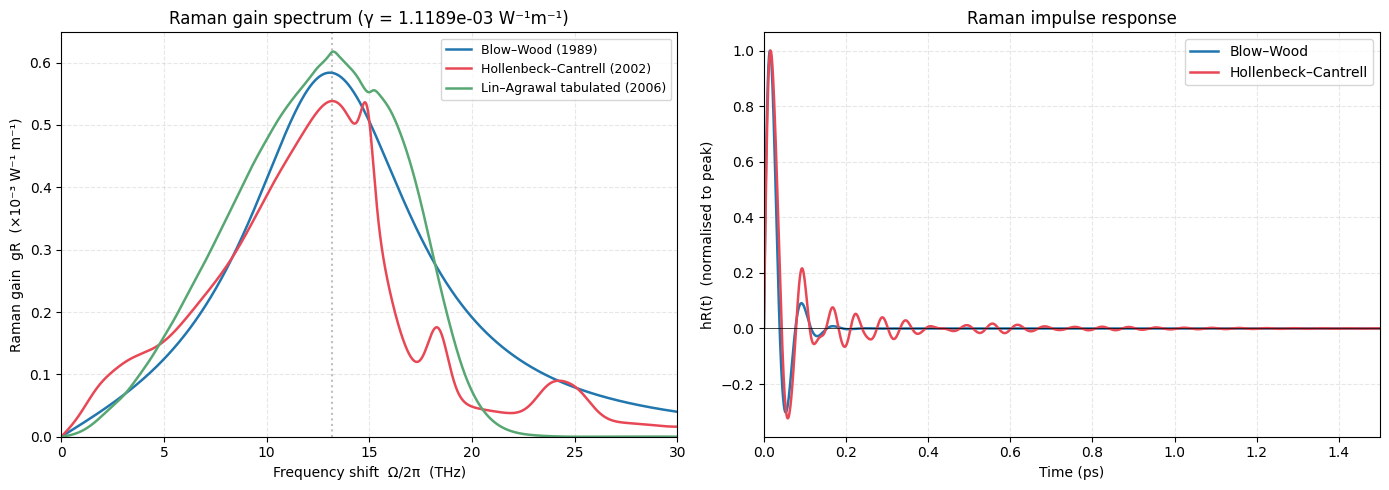

Raman peak gain (BW):  5.835e-04 W⁻¹m⁻¹  at 13.2 THz
Raman peak gain (HC):  5.384e-04 W⁻¹m⁻¹  at 13.2 THz


In [10]:
fparams = deploy.get_fiber_params(dep)
gamma_nl = fparams['gamma']
print(f'Nonlinear coefficient gamma = {gamma_nl:.4e} W⁻¹m⁻¹')
print(f'  (computed from: r0={fparams["r0"]*1e6:.1f} um, '
        f'GeO2={fparams["m_GeO2"]*100:.1f}%, V={fparams["v"]:.3f})')
print()

freq_THz = np.linspace(0.1, 30, 2000)
Omega = 2 * np.pi * freq_THz * 1e12

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Raman gain spectrum
models = {'bw': ('Blow–Wood (1989)', '#2176AE', '-'),
            'hc': ('Hollenbeck–Cantrell (2002)', '#E84855', '-')}
try:
    import raman_tabulated
    models['tabulated'] = ('Lin–Agrawal tabulated (2006)', '#57A773', '-')
except ImportError:
    pass

for model, (label, color, ls) in models.items():
    gR = raman.g_R(Omega, gamma_nl, model=model)
    ax1.plot(freq_THz, gR * 1e3, label=label, color=color, ls=ls, lw=1.8)

ax1.set_xlabel('Frequency shift  Ω/2π  (THz)')
ax1.set_ylabel('Raman gain  gR  (×10⁻³ W⁻¹ m⁻¹)')
ax1.set_title(f'Raman gain spectrum (γ = {gamma_nl:.4e} W⁻¹m⁻¹)')
ax1.legend(fontsize=9)
ax1.set_xlim(0, 30)
ax1.set_ylim(bottom=0)
ax1.axvline(13.2, color='grey', ls=':', alpha=0.5)
ax1.grid(True, ls='--', alpha=0.3)

# Right: impulse response in time domain
t_ps = np.linspace(0, 1.5, 3000)
t_s = t_ps * 1e-12
h_bw = raman.h_R_time(t_s)
h_hc = raman.h_R_time_hc(t_s)

ax2.plot(t_ps, h_bw / h_bw.max(), label='Blow–Wood', color='#2176AE', lw=1.8)
ax2.plot(t_ps, h_hc / h_hc.max(), label='Hollenbeck–Cantrell',
            color='#E84855', lw=1.8)
ax2.set_xlabel('Time (ps)')
ax2.set_ylabel('hR(t)  (normalised to peak)')
ax2.set_title('Raman impulse response')
ax2.legend()
ax2.set_xlim(0, 1.5)
ax2.grid(True, ls='--', alpha=0.3)
ax2.axhline(0, color='k', lw=0.5)

plt.tight_layout()
plt.show()

gR_bw = raman.g_R(raman.RAMAN_OMEGA_R, gamma_nl, model='bw')
gR_hc = raman.g_R(raman.RAMAN_OMEGA_R, gamma_nl, model='hc')
print(f'Raman peak gain (BW):  {gR_bw:.3e} W⁻¹m⁻¹  at 13.2 THz')
print(f'Raman peak gain (HC):  {gR_hc:.3e} W⁻¹m⁻¹  at 13.2 THz')

## 8. Brillouin gain profile

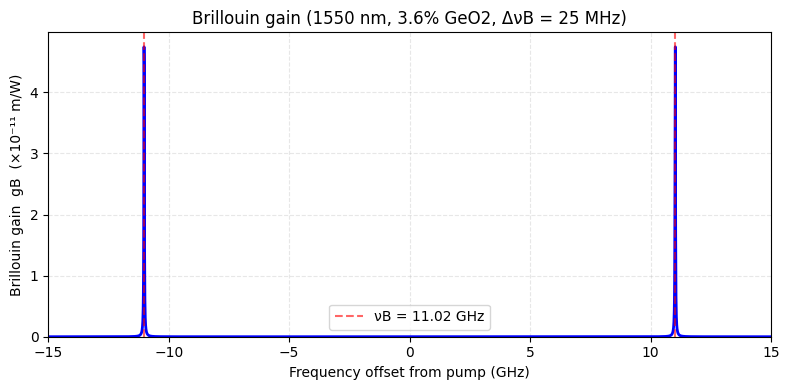

Brillouin shift:     11.02 GHz
Brillouin linewidth: 25 MHz
Peak gain:           5.00e-11 m/W
  (unit: m/W = gain per unit length per unit pump power)


In [12]:
lam_pump = dep['raw_config']['wavelength_nm'] * 1e-9
m_GeO2 = dep['raw_config']['fiber']['core_GeO2_mol_fraction']

prof = brillouin.brillouin_gain_profile(
    lam_pump, freq_range_GHz=(-15, 15), N=4096, m_GeO2=m_GeO2)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(prof['freq_offset_GHz'], prof['g_B_mW'] * 1e11, 'b-', lw=2)
ax.axvline(-prof['nu_B_GHz'], color='r', ls='--', alpha=0.6,
            label=f'νB = {prof["nu_B_GHz"]:.2f} GHz')
ax.axvline(+prof['nu_B_GHz'], color='r', ls='--', alpha=0.6)
ax.set_xlabel('Frequency offset from pump (GHz)')
ax.set_ylabel('Brillouin gain  gB  (×10⁻¹¹ m/W)')
ax.set_title(f'Brillouin gain ({lam_pump*1e9:.0f} nm, '
                f'{m_GeO2*100:.1f}% GeO2, ΔνB = {prof["Gamma_B_MHz"]:.0f} MHz)')
ax.legend()
ax.set_xlim(-15, 15)
ax.set_ylim(bottom=0)
ax.grid(True, ls='--', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Brillouin shift:     {prof["nu_B_GHz"]:.2f} GHz')
print(f'Brillouin linewidth: {prof["Gamma_B_MHz"]:.0f} MHz')
print(f'Peak gain:           {prof["g_B_peak"]:.2e} m/W')
print(f'  (unit: m/W = gain per unit length per unit pump power)')

## 9. Monte Carlo — long spun fiber with hinge model

Simulate a 10 km spun fiber link split into 20 segments with random rotator
hinges between them. Core noncircularity varies randomly per segment.
500 Monte Carlo trials → DGD histogram should be Maxwellian.

This follows the approach in Appendix E (Fig. E.1) and the BIFROST paper
(arXiv:2510.01212, Fig. 6), which validates the hinge model against the
expected √L scaling and Maxwellian DGD statistics.

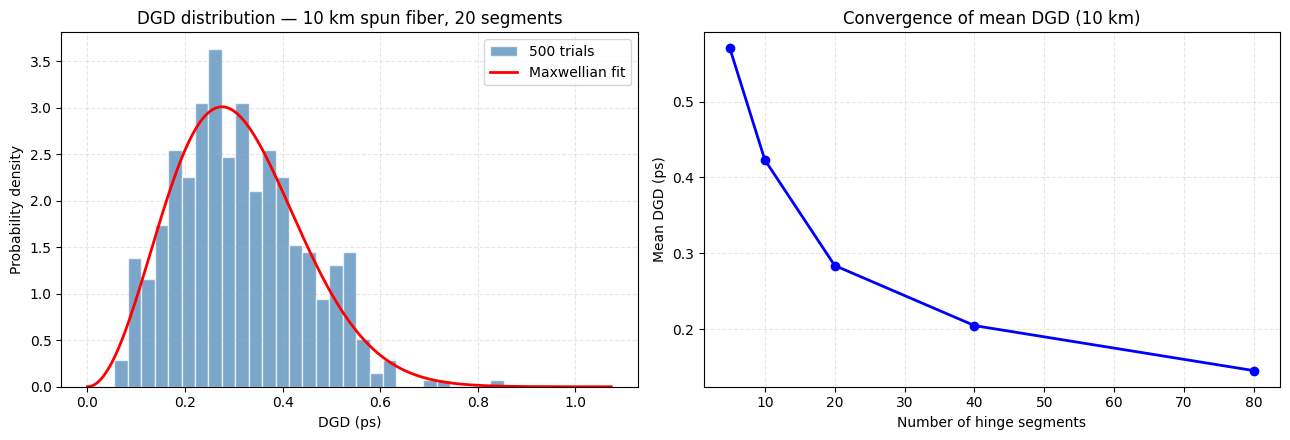

Mean DGD: 0.312 ps
Std DGD:  0.129 ps
PMD coefficient: 0.0986 ps/sqrt(km)
Corning SMF-28e+ spec: < 0.06 ps/sqrt(km)


In [21]:
np.random.seed(42)

Ltot = 10e3        # 10 km total
N_segments = 20    # 20 segments (avg 500 m each)
N_mc = 500         # Monte Carlo trials
xi0_mc = 50.0      # spin rate
omega_mc = 10.0    # → m = 10

dgd_samples = []

for trial in range(N_mc):
    segDict = {
        'L0': Ltot / N_segments,
        'T0': 20, 'Tref': 20,
        'epsilon': np.random.normal(1.003, 0.002, N_segments).clip(1.0001),
        'm0': 0.036, 'm1': 0, 'r0': 4.1e-6, 'r1': 62.5e-6,
        'rc': 0, 'tf': 0, 'tr': 0,
        'xi0': xi0_mc,
        'spin_type': 'sinusoidal',
        'omega': omega_mc,
    }
    alpha_data = np.random.normal(size=(N_segments - 1, 4))
    hingeDict = {'alpha': alpha_data}

    fiber = bf.Fiber(1550e-9, segDict, hingeDict, N0=N_segments,
                     hingeType=1, hingeStart=False, hingeEnd=False)
    dgd_samples.append(fiber.calcDGD() * 1e12)

dgd_arr = np.array(dgd_samples)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: histogram with Maxwellian fit
from scipy.stats import maxwell
bins = np.linspace(0, dgd_arr.max() * 1.3, 40)
ax1.hist(dgd_arr, bins=bins, density=True, alpha=0.7, color='steelblue',
         edgecolor='white', label=f'{N_mc} trials')
params = maxwell.fit(dgd_arr, floc=0)
x_fit = np.linspace(0, dgd_arr.max() * 1.3, 200)
ax1.plot(x_fit, maxwell.pdf(x_fit, *params), 'r-', lw=2, label='Maxwellian fit')
ax1.set_xlabel('DGD (ps)')
ax1.set_ylabel('Probability density')
ax1.set_title(f'DGD distribution — {Ltot/1e3:.0f} km spun fiber, {N_segments} segments')
ax1.legend()
ax1.grid(True, ls='--', alpha=0.3)

# Right: convergence of mean DGD vs segment count
N_seg_arr = [5, 10, 20, 40, 80]
mean_dgds = []
for Ns in N_seg_arr:
    dgds = []
    for _ in range(200):
        sd = {
            'L0': Ltot / Ns, 'T0': 20, 'Tref': 20,
            'epsilon': np.random.normal(1.003, 0.002, Ns).clip(1.0001),
            'm0': 0.036, 'm1': 0, 'r0': 4.1e-6, 'r1': 62.5e-6,
            'rc': 0, 'tf': 0, 'tr': 0,
            'xi0': xi0_mc, 'spin_type': 'sinusoidal', 'omega': omega_mc,
        }
        hd = {'alpha': np.random.normal(size=(Ns-1, 4))}
        fib = bf.Fiber(1550e-9, sd, hd, N0=Ns, hingeType=1,
                       hingeStart=False, hingeEnd=False)
        dgds.append(fib.calcDGD() * 1e12)
    mean_dgds.append(np.mean(dgds))

ax2.plot(N_seg_arr, mean_dgds, 'bo-', lw=2)
ax2.set_xlabel('Number of hinge segments')
ax2.set_ylabel('Mean DGD (ps)')
ax2.set_title(f'Convergence of mean DGD ({Ltot/1e3:.0f} km)')
ax2.grid(True, ls='--', alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Mean DGD: {dgd_arr.mean():.3f} ps')
print(f'Std DGD:  {dgd_arr.std():.3f} ps')
print(f'PMD coefficient: {dgd_arr.mean() / np.sqrt(Ltot/1e3):.4f} ps/sqrt(km)')
print(f'Corning SMF-28e+ spec: < 0.06 ps/sqrt(km)')

## 10. Spun vs unspun Monte Carlo comparison

Same 10 km link, but compare unspun (spinning off) vs spun fiber.

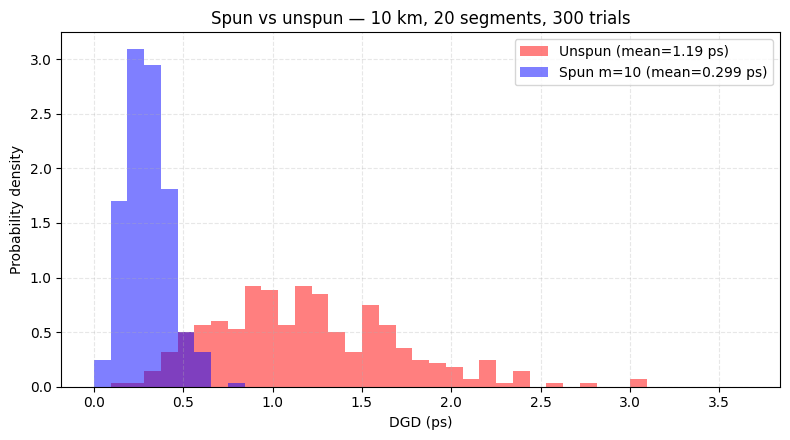

Unspun mean DGD: 1.194 ps
Spun mean DGD:   0.299 ps
Suppression ratio: 4.0×


In [20]:
np.random.seed(123)
N_mc2 = 300

dgd_unspun_mc = []
dgd_spun_mc = []

for _ in range(N_mc2):
    eps_arr = np.random.normal(1.003, 0.002, N_segments).clip(1.0001)
    alpha_data = np.random.normal(size=(N_segments - 1, 4))

    # Unspun
    sd_u = {
        'L0': Ltot / N_segments, 'T0': 20, 'Tref': 20,
        'epsilon': eps_arr.copy(),
        'm0': 0.036, 'm1': 0, 'r0': 4.1e-6, 'r1': 62.5e-6,
        'rc': 0, 'tf': 0, 'tr': 0,
    }
    fib_u = bf.Fiber(1550e-9, sd_u, {'alpha': alpha_data.copy()}, N0=N_segments,
                     hingeType=1, hingeStart=False, hingeEnd=False)
    dgd_unspun_mc.append(fib_u.calcDGD() * 1e12)

    # Spun (same random epsilon and hinges)
    sd_s = {
        'L0': Ltot / N_segments, 'T0': 20, 'Tref': 20,
        'epsilon': eps_arr.copy(),
        'm0': 0.036, 'm1': 0, 'r0': 4.1e-6, 'r1': 62.5e-6,
        'rc': 0, 'tf': 0, 'tr': 0,
        'xi0': xi0_mc, 'spin_type': 'sinusoidal', 'omega': omega_mc,
    }
    fib_s = bf.Fiber(1550e-9, sd_s, {'alpha': alpha_data.copy()}, N0=N_segments,
                     hingeType=1, hingeStart=False, hingeEnd=False)
    dgd_spun_mc.append(fib_s.calcDGD() * 1e12)

fig, ax = plt.subplots(figsize=(8, 4.5))
bins_all = np.linspace(0, max(dgd_unspun_mc) * 1.2, 40)
ax.hist(dgd_unspun_mc, bins=bins_all, density=True, alpha=0.5,
        color='red', label=f'Unspun (mean={np.mean(dgd_unspun_mc):.2f} ps)')
ax.hist(dgd_spun_mc, bins=bins_all, density=True, alpha=0.5,
        color='blue', label=f'Spun m=10 (mean={np.mean(dgd_spun_mc):.3f} ps)')
ax.set_xlabel('DGD (ps)')
ax.set_ylabel('Probability density')
ax.set_title(f'Spun vs unspun — {Ltot/1e3:.0f} km, {N_segments} segments, {N_mc2} trials')
ax.legend()
ax.grid(True, ls='--', alpha=0.3)
plt.tight_layout()
plt.show()

ratio = np.mean(dgd_unspun_mc) / np.mean(dgd_spun_mc)
print(f'Unspun mean DGD: {np.mean(dgd_unspun_mc):.3f} ps')
print(f'Spun mean DGD:   {np.mean(dgd_spun_mc):.3f} ps')
print(f'Suppression ratio: {ratio:.1f}×')

## 11. Monte Carlo vs exact deployment DGD

Compare the DGD from the exact deployment (with its specific layout of underground,
aerial, and indoor segments, pole wraps, paddle controller, and splices) to Monte Carlo
ensembles that use the same total length, spin parameters, and average temperature but
replace the detailed structure with N random hinge segments. As N increases, the
Monte Carlo mean should converge, and the exact deployment DGD should sit somewhere
within the distribution.

Deployment: L = 800.8 m, ξ₀ = 50 rad/m, ω = 10 rad/m, m = 10
Weighted avg temperature: 21.9 °C
Exact deployment DGD: 0.0282 ps

  N= 20: mean=0.0986 ps, std=0.0441 ps  (400 trials)
  N=100: mean=0.0431 ps, std=0.0179 ps  (400 trials)
  N=500: mean=0.0191 ps, std=0.0079 ps  (400 trials)


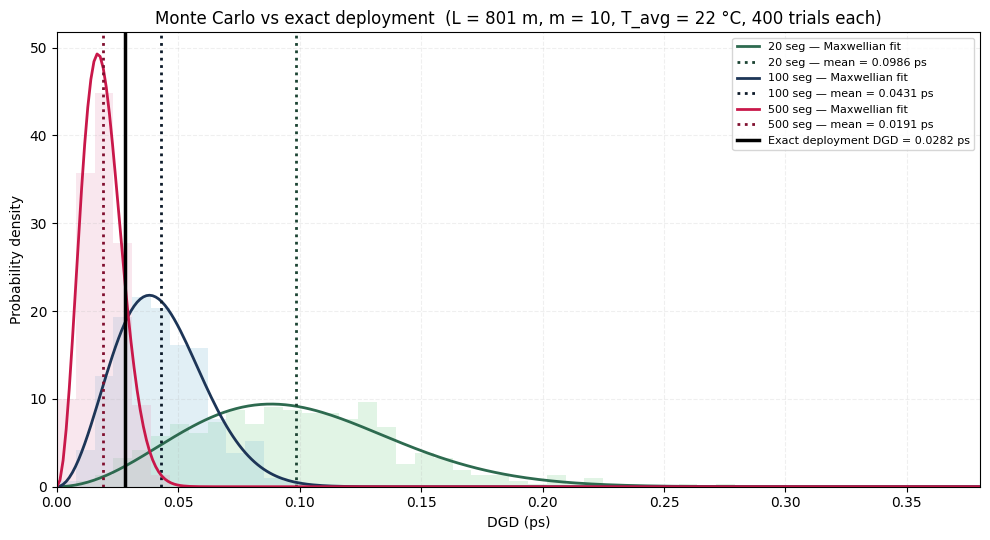

In [22]:
# === Extract parameters from the deployment ===
cfg = dep['raw_config']
L_total = deploy.compute_total_length(dep)
xi0_dep = cfg['fiber']['spinning']['spin_rate_rad_per_m']
omega_dep = cfg['fiber']['spinning']['spin_modulation_omega_rad_per_m']
m_dep = 2 * xi0_dep / omega_dep

# Weighted average temperature (weight by segment length)
T_sum, L_sum = 0.0, 0.0
for f in dep['fibers']:
    if hasattr(f, 'T0') and f.L0 > 0:
        T_sum += f.T0 * f.L0
        L_sum += f.L0
T_avg = T_sum / L_sum

# Exact DGD of the deployment
dgd_exact = deploy.compute_dgd(dep) * 1e12  # ps

print(f"Deployment: L = {L_total:.1f} m, ξ₀ = {xi0_dep} rad/m, "
      f"ω = {omega_dep} rad/m, m = {m_dep:.0f}")
print(f"Weighted avg temperature: {T_avg:.1f} °C")
print(f"Exact deployment DGD: {dgd_exact:.4f} ps")
print()

# === Monte Carlo for 3 segment counts ===
np.random.seed(77)
N_mc = 400
seg_counts = [20, 100, 500]
colors = {
    20:  {'hist': '#88d498', 'fit': '#2d6a4f', 'mean': '#1b4332', 'label': '20 seg'},
    100: {'hist': '#89c2d9', 'fit': '#1d3557', 'mean': '#0d1b2a', 'label': '100 seg'},
    500: {'hist': '#e8a0bf', 'fit': '#c9184a', 'mean': '#800f2f', 'label': '500 seg'},
}

mc_results = {}
for Ns in seg_counts:
    dgds = []
    for _ in range(N_mc):
        sd = {
            'L0': L_total / Ns,
            'T0': T_avg, 'Tref': 20,
            'epsilon': np.random.normal(1.003, 0.002, Ns).clip(1.0001),
            'm0': 0.036, 'm1': 0,
            'r0': 4.1e-6, 'r1': 62.5e-6,
            'rc': 0, 'tf': 0, 'tr': 0,
            # 'xi0': xi0_dep,
            # 'spin_type': 'sinusoidal',
            # 'omega': omega_dep,
        }
        hd = {'alpha': np.random.normal(size=(Ns - 1, 4))}
        fib = bf.Fiber(1550e-9, sd, hd, N0=Ns,
                       hingeType=1, hingeStart=False, hingeEnd=False)
        dgds.append(fib.calcDGD() * 1e12)
    mc_results[Ns] = np.array(dgds)
    print(f"  N={Ns:>3d}: mean={np.mean(dgds):.4f} ps, "
          f"std={np.std(dgds):.4f} ps  ({N_mc} trials)")

# === Plot ===
from scipy.stats import maxwell

fig, ax = plt.subplots(figsize=(10, 5.5))

# Determine common bin range
all_dgds = np.concatenate(list(mc_results.values()))
bin_max = max(all_dgds.max(), dgd_exact) * 1.4
bins = np.linspace(0, bin_max, 50)
x_fit = np.linspace(0, bin_max, 300)

for Ns in seg_counts:
    c = colors[Ns]
    dgds = mc_results[Ns]
    mean_dgd = np.mean(dgds)

    # Histogram
    ax.hist(dgds, bins=bins, density=True, alpha=0.25,
            color=c['hist'], edgecolor='none', label=None)

    # Maxwellian fit
    params = maxwell.fit(dgds, floc=0)
    ax.plot(x_fit, maxwell.pdf(x_fit, *params),
            color=c['fit'], lw=2, label=f'{c["label"]} — Maxwellian fit')

    # Mean dotted line
    ax.axvline(mean_dgd, color=c['mean'], ls=':', lw=2,
               label=f'{c["label"]} — mean = {mean_dgd:.4f} ps')

# Exact deployment DGD
ax.axvline(dgd_exact, color='black', ls='-', lw=2.5,
           label=f'Exact deployment DGD = {dgd_exact:.4f} ps')

ax.set_xlabel('DGD (ps)')
ax.set_ylabel('Probability density')
ax.set_title(f'Monte Carlo vs exact deployment  '
             f'(L = {L_total:.0f} m, m = {m_dep:.0f}, '
             f'T_avg = {T_avg:.0f} °C, {N_mc} trials each)')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, ls='--', alpha=0.2)
ax.set_xlim(0, bin_max)

plt.tight_layout()
plt.show()

## 12. Per-section Monte Carlo breakdown

Repeat the Monte Carlo vs exact comparison for each section individually.
For the aerial section, we isolate just the straight spun runs between pole
wraps (excluding the pole wraps themselves), since we want to see how well the
homogeneous Monte Carlo captures a uniform spun segment without deterministic
bending perturbations.

underground   L =   500.0 m  T = 15 °C  exact DGD = 0.0403 ps  (2 straight segments)
aerial        L =   260.0 m  T = 35 °C  exact DGD = 0.0137 ps  (3 straight segments)
indoor        L =    35.0 m  T = 22 °C  exact DGD = 0.0026 ps  (2 straight segments)


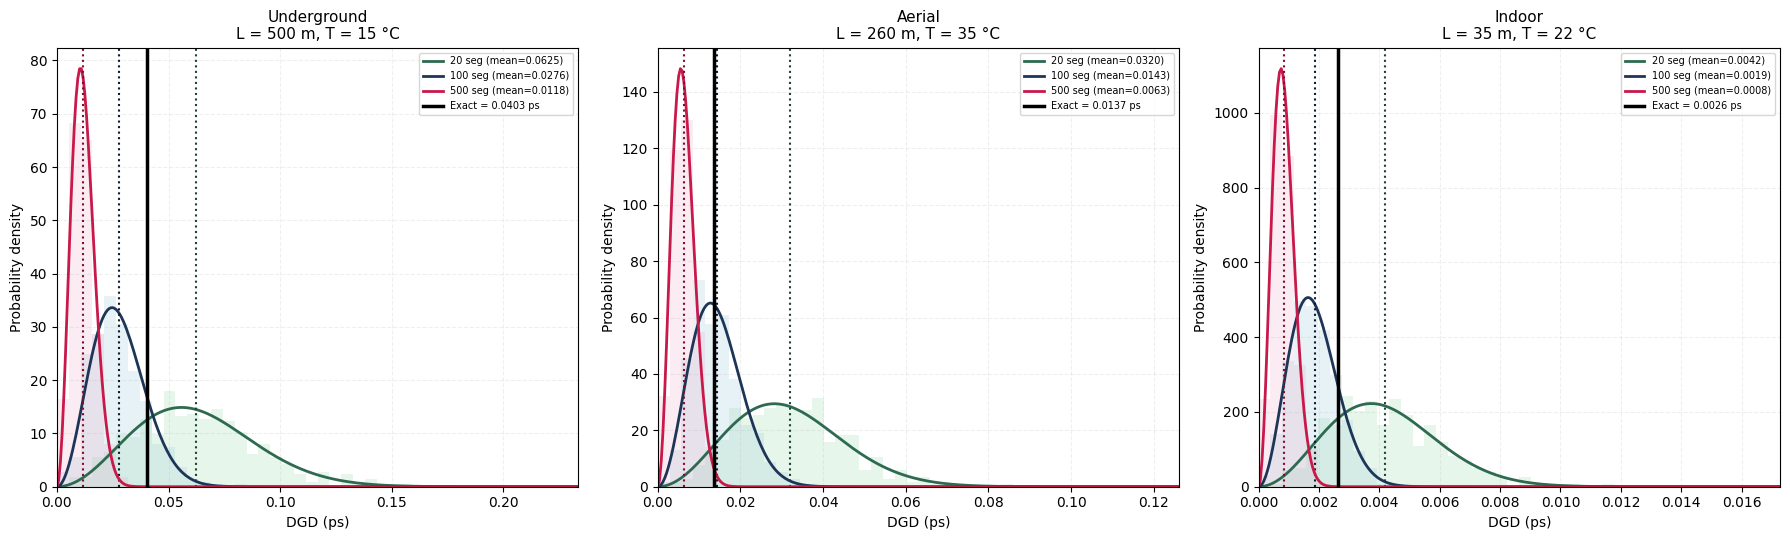

Section           L (m)  Exact (ps)                            Note
--------------------------------------------------------------------
underground         500      0.0403                                
aerial              260      0.0137          straight segments only
indoor               35      0.0026                                


In [23]:
# === Build per-section sub-deployments ===
# For each section, extract just the SpunFiberLength objects (straight spun runs)
# and compute their chained Jones matrix and DGD.

def section_dgd(objects, w0=1550e-9, dw0=0.1e-9):
    """Compute DGD for a chain of fiber objects."""
    if len(objects) == 0:
        return 0.0

    def jones_at(wavelength):
        old = []
        for f in objects:
            old.append(getattr(f, 'w0', None))
            if hasattr(f, 'w0'):
                f.w0 = wavelength
        J = np.eye(2, dtype=complex)
        for f in objects:
            J = f.J0 @ J
        for f, ow in zip(objects, old):
            if ow is not None:
                f.w0 = ow
        return J

    Jb = jones_at(w0)
    Ja = jones_at(w0 - dw0)
    Jc = jones_at(w0 + dw0)

    matM = Ja @ np.linalg.inv(Jb)
    vM = np.linalg.eigvals(matM)
    dgdM = np.abs(np.angle(vM[0]/vM[1]) / ((2*np.pi*299792458)/w0**2 * dw0))

    matP = Jc @ np.linalg.inv(Jb)
    vP = np.linalg.eigvals(matP)
    dgdP = np.abs(np.angle(vP[0]/vP[1]) / ((2*np.pi*299792458)/w0**2 * dw0))

    return (dgdM + dgdP) / 2

# Define which objects to use per section
section_specs = []
for sec in dep['sections']:
    name = sec['name']
    env = sec['environment']

    # Filter: only SpunFiberLength objects (straight spun runs)
    straight_objs = [f for f in sec['objects']
                     if type(f).__name__ == 'SpunFiberLength']

    if len(straight_objs) == 0:
        continue

    L_sec = sum(f.L0 for f in straight_objs)
    T_sec = np.mean([f.T0 for f in straight_objs])
    dgd_sec = section_dgd(straight_objs) * 1e12

    section_specs.append({
        'name': name,
        'env': env,
        'objects': straight_objs,
        'L': L_sec,
        'T': T_sec,
        'dgd_exact': dgd_sec,
    })

    print(f"{env:12s}  L = {L_sec:>7.1f} m  T = {T_sec:.0f} °C  "
          f"exact DGD = {dgd_sec:.4f} ps  "
          f"({len(straight_objs)} straight segments)")

# === Monte Carlo for each section ===
np.random.seed(99)
N_mc = 400
seg_counts = [20, 100, 500]

colors_by_N = {
    20:  {'hist': '#88d498', 'fit': '#2d6a4f', 'mean': '#1b4332'},
    100: {'hist': '#89c2d9', 'fit': '#1d3557', 'mean': '#0d1b2a'},
    500: {'hist': '#e8a0bf', 'fit': '#c9184a', 'mean': '#800f2f'},
}

fig, axes = plt.subplots(1, len(section_specs), figsize=(6 * len(section_specs), 5.5))
if len(section_specs) == 1:
    axes = [axes]

for ax, spec in zip(axes, section_specs):
    all_mc_dgds = []

    for Ns in seg_counts:
        dgds = []
        for _ in range(N_mc):
            sd = {
                'L0': spec['L'] / Ns,
                'T0': spec['T'], 'Tref': 20,
                'epsilon': np.random.normal(1.003, 0.002, Ns).clip(1.0001),
                'm0': 0.036, 'm1': 0,
                'r0': 4.1e-6, 'r1': 62.5e-6,
                'rc': 0, 'tf': 0, 'tr': 0,
                # spin_type and omega removed: hinge-only MC, no spin
            }
            hd = {'alpha': np.random.normal(size=(Ns - 1, 4))}
            fib = bf.Fiber(1550e-9, sd, hd, N0=Ns,
                           hingeType=1, hingeStart=False, hingeEnd=False)
            dgds.append(fib.calcDGD() * 1e12)
        dgds = np.array(dgds)
        all_mc_dgds.append(dgds)

    # Determine bin range
    all_vals = np.concatenate(all_mc_dgds + [np.array([spec['dgd_exact']])])
    bin_max = max(all_vals.max(), spec['dgd_exact']) * 1.5
    bins = np.linspace(0, bin_max, 45)
    x_fit = np.linspace(0, bin_max, 300)

    for Ns, dgds in zip(seg_counts, all_mc_dgds):
        c = colors_by_N[Ns]
        mean_d = np.mean(dgds)

        ax.hist(dgds, bins=bins, density=True, alpha=0.2,
                color=c['hist'], edgecolor='none')
        params = maxwell.fit(dgds, floc=0)
        ax.plot(x_fit, maxwell.pdf(x_fit, *params),
                color=c['fit'], lw=2, label=f'{Ns} seg (mean={mean_d:.4f})')
        ax.axvline(mean_d, color=c['mean'], ls=':', lw=1.5)

    ax.axvline(spec['dgd_exact'], color='black', ls='-', lw=2.5,
               label=f'Exact = {spec["dgd_exact"]:.4f} ps')

    ax.set_xlabel('DGD (ps)')
    ax.set_ylabel('Probability density')
    ax.set_title(f'{spec["env"].capitalize()}\n'
                 f'L = {spec["L"]:.0f} m, T = {spec["T"]:.0f} °C',
                 fontsize=11)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, ls='--', alpha=0.2)
    ax.set_xlim(0, bin_max)

plt.tight_layout()
plt.show()

# Print summary table
print(f"{'Section':14s}  {'L (m)':>7}  {'Exact (ps)':>10}  "
      f"{'Note':>30}")
print('-' * 68)
for spec in section_specs:
    note = "straight segments only" if spec['env'] == 'aerial' else ""
    print(f"{spec['env']:14s}  {spec['L']:>7.0f}  {spec['dgd_exact']:>10.4f}  "
          f"{note:>30}")